In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import libertem.api as lt
from libertem.udf.raw import PickUDF
from libertem.udf.sum import SumUDF
from libertem.udf import UDF

In [3]:
from scipy.ndimage import shift, center_of_mass
from skimage.transform import downscale_local_mean

In [4]:
%matplotlib widget

# Load Data

In [5]:
ctx =  lt.Context()

In [6]:
ds = ctx.load("dm",r"F:\FeGaB\2026\For Manuscript\B16\STEM SI.dm4", dataset_index = 3)
ds.shape, ds.dtype

((256, 256, 128, 128), dtype('uint32'))

# Calculate Average Diffraction Pattern

In [7]:
udf = SumUDF()

In [8]:
avgDP = ctx.run_udf(dataset = ds, udf = udf)
avgDP = avgDP["intensity"].data

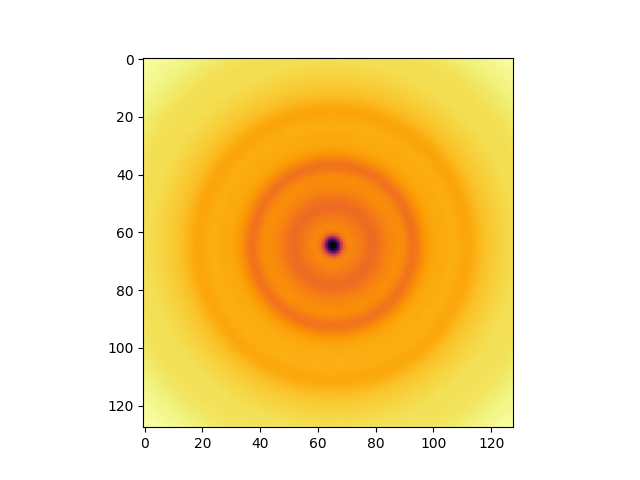

In [9]:
plt.figure()
plt.imshow(avgDP, cmap = "inferno_r", norm = 'log')

# Shift Each Frame to the Center

In [31]:
class CenterFrame(UDF):
    def __init__(self, center, radius, *args, **kwargs):
        super().__init__(*args, center = center, radius = radius, **kwargs)

    def get_result_buffers(self):
        return {
            "ShiftedDP": self.buffer(kind = 'nav', dtype = 'uint32', extra_shape = (self.meta.dataset_shape[2], self.meta.dataset_shape[3]))
        }        

    def process_frame(self, frame):
        r00, c00 = self.meta.dataset_shape[2]//2, self.meta.dataset_shape[3]//2
        r0, c0 = self.params.center
        r = self.params.radius

        rr, cc = np.mgrid[0:self.meta.dataset_shape[2], 0:self.meta.dataset_shape[3]]
        mask = (rr - r0)**2 + (cc - c0)**2 <= r**2

        r_com, c_com = center_of_mass(frame*mask)
        shift_r, shift_c = r00 - r_com, c00 - c_com
        shifted_frame = shift(frame, shift = (int(shift_r), int(shift_c)), order = 1)

        self.results.ShiftedDP[:] = shifted_frame


In [32]:
CenteredDS = ctx.run_udf(dataset=ds, udf = CenterFrame(center = (64, 64), radius = 5), progress = True)

Partitions 0/8, Frames:   0%|          | 0/65536 [00:00<?, ?it/s]

In [33]:
CenteredDS_data = CenteredDS["ShiftedDP"].data 

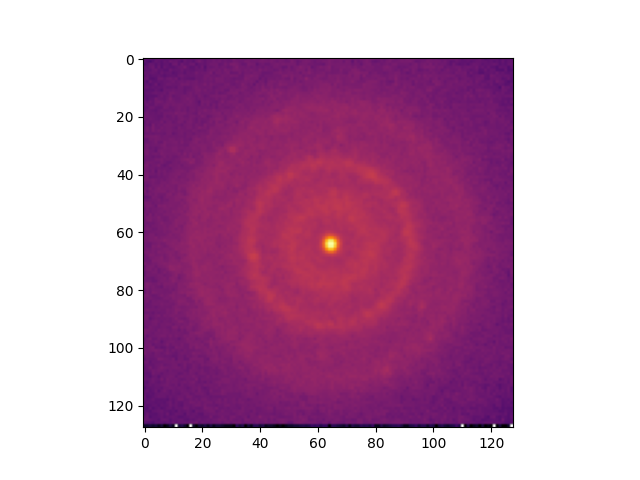

In [34]:
plt.figure()
plt.imshow(CenteredDS_data[0:10, 0:10].mean(axis = (0,1)), cmap = "inferno", norm ='log')

In [35]:
np.save("Preprocessed.npy", CenteredDS_data)

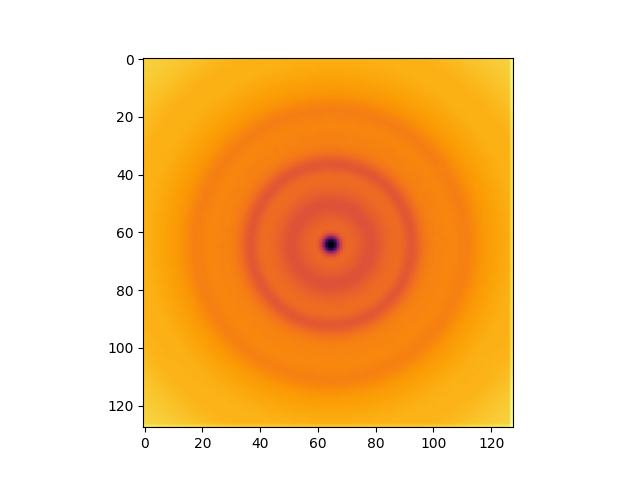

In [36]:
plt.figure()
plt.imshow(CenteredDS_data.mean((0,1)), cmap = "inferno_r", norm = 'log')